# Multi-LLM Debate System — Demo Notebook

**Course requirement:** this repository includes notebooks + README + run instructions.

1. Install: `pip install -r requirements.txt` (from repo root)
2. Copy `.env.example` → `.env` and add API keys
3. Run the cells below to inspect evaluation results

For full batch runs, use from repo root:
- `python scripts/check_apis.py`
- `python scripts/run_debate.py --limit 2`
- `python scripts/run_evaluation.py`

In [1]:
import json
import sys
from pathlib import Path

# Repo root (parent of notebooks/)
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
elif not (ROOT / "src").exists():
    ROOT = ROOT.parent  # fallback if launched from notebooks/

sys.path.insert(0, str(ROOT))
print("Repo root:", ROOT)
print("Results:", len(list((ROOT / "results").glob("*/debate.json"))), "debate files")

Repo root: c:\Users\tamar\OneDrive\Desktop\6th semester\appliedLLM\debatesystem
Results: 27 debate files


In [2]:
# Load evaluation summary (generated by scripts/run_evaluation.py)
summary_path = ROOT / "plots" / "summary.json"
if summary_path.exists():
    summary = json.loads(summary_path.read_text(encoding="utf-8"))
    print("Evaluation summary:")
    for key, value in summary.items():
        if isinstance(value, float):
            print(f"  {key}: {value:.1%}")
        else:
            print(f"  {key}: {value}")
else:
    print("No summary yet. Run: python scripts/run_evaluation.py")

Evaluation summary:
  overall_accuracy: 55.6%
  improvement_rate: 29.6%
  consensus_rate_initial: 7.4%
  consensus_rate_refined: 29.6%
  refinement_hurt_rate: 18.5%
  judge_missed_best_rate: 7.4%
  judge_accuracy_when_disagree: 52.0%
  single_llm_accuracy: 25.9%
  voting_accuracy: 48.1%


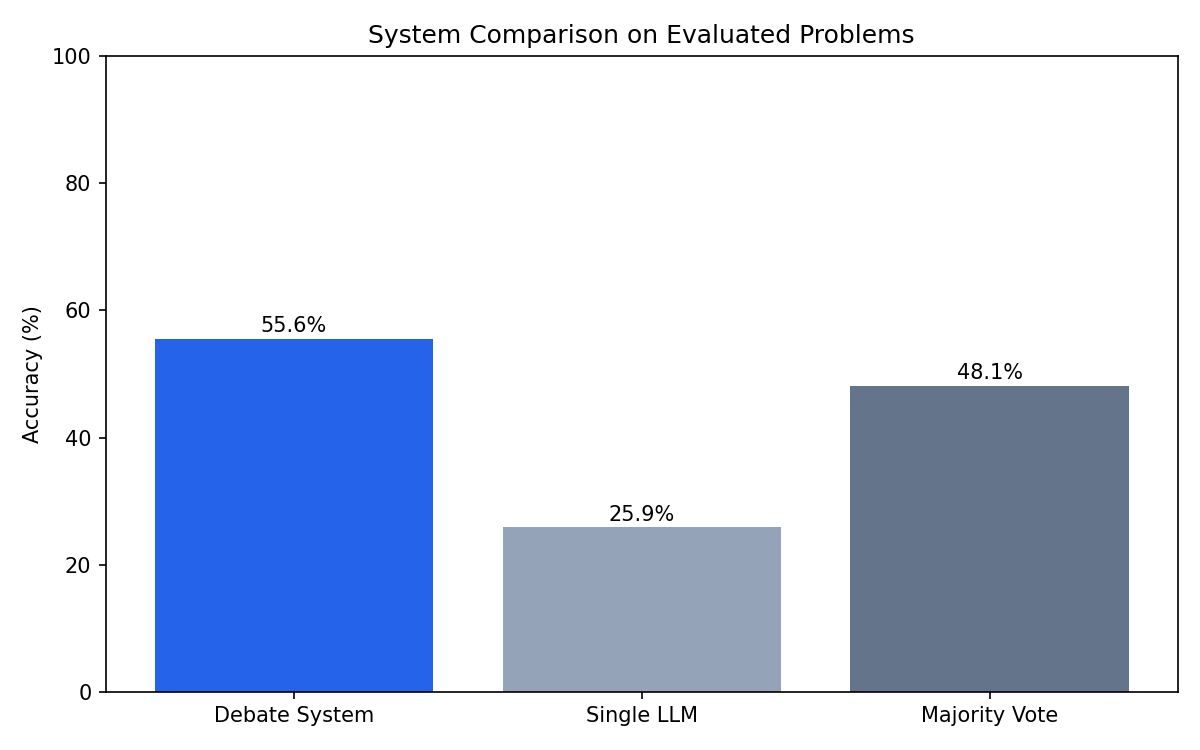

In [3]:
# Display accuracy comparison plot
from IPython.display import Image, display

plot_path = ROOT / "plots" / "accuracy_comparison.png"
if plot_path.exists():
    display(Image(filename=str(plot_path)))
else:
    print("Plot not found. Run: python scripts/run_evaluation.py")

In [4]:
# Optional: regenerate plots from results/ (no new API debate calls)
from src.config import PLOTS_DIR, RESULTS_DIR
from src.evaluation import run_evaluation

if list(RESULTS_DIR.glob("*/debate.json")):
    new_summary = run_evaluation(RESULTS_DIR, PLOTS_DIR)
    print("Regenerated summary:")
    print(json.dumps(new_summary, indent=2))
else:
    print("No results/. Run: python scripts/run_debate.py --limit 2")

Regenerated summary:
{
  "overall_accuracy": 0.5555555555555556,
  "improvement_rate": 0.2962962962962963,
  "consensus_rate_initial": 0.07407407407407407,
  "consensus_rate_refined": 0.2962962962962963,
  "refinement_hurt_rate": 0.18518518518518517,
  "judge_missed_best_rate": 0.07407407407407407,
  "judge_accuracy_when_disagree": 0.52,
  "single_llm_accuracy": 0.25925925925925924,
  "voting_accuracy": 0.48148148148148145
}


## live debate (uses APIs)

 This calls ~25 LLM requests for one problem.

In [ ]:
LIVE_RUN = True
if LIVE_RUN:
    from src.config import DATA_DIR, RESULTS_DIR, get_backends, require_api_keys
    from src.llm import build_clients
    from src.pipeline import DebatePipeline

    require_api_keys()
    problems = json.loads((DATA_DIR / "problems_medium.json").read_text(encoding="utf-8"))
    problem = problems[0]
    backends = get_backends()
    clients = build_clients(backends)
    pipeline = DebatePipeline(backends, grader_client=clients["openai_strong"], verbose=True)
    result = pipeline.run_problem(problem, save_dir=RESULTS_DIR / problem["id"])
    print("Winner:", result["winner"], "| Final answer:", result["final_answer"])


[medium_01] Starting debate pipeline...
[medium_01] Stage 0: role preference (openai_mini)...
[medium_01] Stage 0 (openai_mini) - waiting for API...
[medium_01] Stage 0 (openai_mini) - done (4.6s)
[medium_01] Stage 0: role preference (openai_strong)...
[medium_01] Stage 0 (openai_strong) - waiting for API...
[medium_01] Stage 0 (openai_strong) - done (2.1s)
[medium_01] Stage 0: role preference (gemini)...
[medium_01] Stage 0 (gemini) - waiting for API...
[medium_01] Stage 0 (gemini) - done (3.4s)
[medium_01] Stage 0: role preference (groq)...
[medium_01] Stage 0 (groq) - waiting for API...
[medium_01] Stage 0 (groq) - done (1.0s)
[medium_01] Stage 0.5: role ballot (openai_mini)...
[medium_01] Stage 0.5 (openai_mini) - waiting for API...
[medium_01] Stage 0.5 (openai_mini) - done (1.7s)
[medium_01] Stage 0.5: role ballot (openai_strong)...
[medium_01] Stage 0.5 (openai_strong) - waiting for API...
[medium_01] Stage 0.5 (openai_strong) - done (2.3s)
[medium_01] Stage 0.5: role ballot (g